# 03 — Feature Engineering

**Phase 3.** Build the per-customer feature table in **three lanes** (doc 17) and run the
**Feature-EDA checkpoint** that *justifies* the transforms before clustering:
- **skew** → which columns get `log1p` (doc 09)
- **correlations** → AvgBasket=M/F redundancy is definitional; check F–M / Tenure structure (doc 09)
- **wholesaler tail** → decide the bulk-flag cutoff (doc 17)

Logic lives in `src/features.py` (unit-tested); this notebook runs it, makes the EDA-driven
decisions, and saves the feature tables.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src import features, utils

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
PHASE = "03_features"

In [2]:
tx = pd.read_parquet(utils.DATA_PROCESSED / "clean_transactions.parquet")
non_purchases = pd.read_parquet(utils.DATA_PROCESSED / "non_purchases.parquet")

core = features.build_core_features(tx)        # R / F / M / Tenure / AvgBasket (raw)
print("core features:", core.shape)
core.describe().round(1)

core features: (5852, 5)


,Recency,Frequency,Monetary,Tenure,AvgBasket
count,"5,852.00","5,852.00","5,852.00","5,852.00","5,852.00"
mean,221.70,6.30,"2,969.40",495.50,389.20
std,208.50,12.70,"14,599.30",223.20,"1,255.40"
min,22.00,1.00,3.00,22.00,3.00
25%,47.00,1.00,343.10,333.00,178.70
50%,117.00,3.00,874.90,551.00,282.20
75%,401.00,7.00,"2,281.60",688.00,416.90
max,760.00,373.00,"608,821.60",760.00,"84,236.20"


## Feature-EDA 1 — Skew: which columns need `log1p`? (doc 09)

We **measure** the skew rather than assume it. Rule: `log1p` a clustering feature if its raw
skewness is high (> 1) *and* logging meaningfully reduces it. We expect F/M skewed, Recency/Tenure
(bounded time spans) mild — exactly doc 09 / Decision 2.

In [3]:
CLUSTER_COLS = ["Recency", "Frequency", "Monetary", "Tenure"]   # AvgBasket excluded (= M/F, doc 09)
sk = pd.DataFrame({"raw": core.skew(), "log1p": np.log1p(core).skew()}).round(2)
print(sk.to_string())

LOG_COLS = [c for c in CLUSTER_COLS if core[c].skew() > 1]
print("\n-> log1p these clustering columns:", LOG_COLS)

            raw  log1p
Recency    0.89   0.02
Frequency 12.04   1.00
Monetary  25.61   0.27
Tenure    -0.62  -1.65
AvgBasket 53.28   0.05

-> log1p these clustering columns: ['Frequency', 'Monetary']


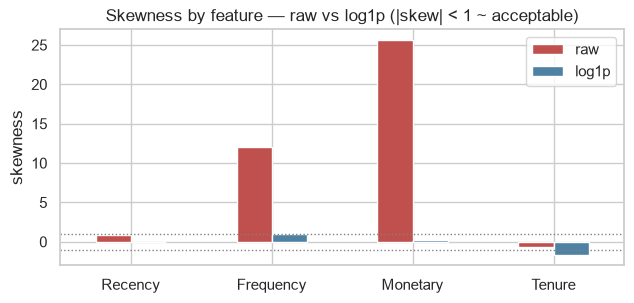

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
sk.loc[CLUSTER_COLS].plot.bar(ax=ax, color=["#c0504d", "#4f81a3"])
ax.axhline(1, color="grey", ls=":", lw=1)
ax.axhline(-1, color="grey", ls=":", lw=1)
ax.set_title("Skewness by feature — raw vs log1p (|skew| < 1 ~ acceptable)")
ax.set_ylabel("skewness")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "skewness.png"), dpi=150, bbox_inches="tight")
plt.show()

## Feature-EDA 2 — Correlations (doc 09)

**AvgBasket is excluded from clustering because it is a *deterministic function* of the others —
`AvgBasket = Monetary / Frequency` exactly — so it carries no new information.** That redundancy is
*definitional*, not something a correlation has to prove (and note: under `log1p`, the exact
`log(M) − log(F)` identity does **not** hold, so AvgBasket's correlation below is only moderate —
correlation is not the same as functional dependence).

The heatmap instead corroborates two design points: **Frequency–Monetary are strongly associated
(~0.85 → hypothesis H3, doc 05)**, and **Tenure correlates only mildly (≤ 0.41) with the others, so
it adds independent signal** (it stays a clustering feature, not dropped).

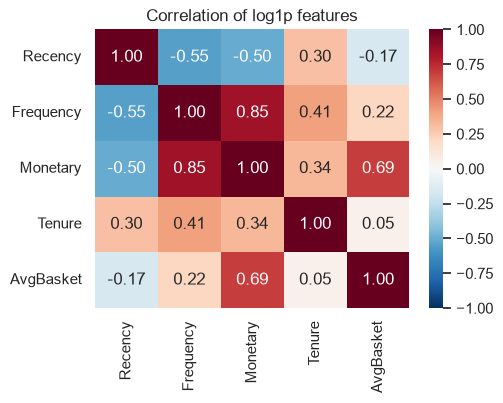

In [5]:
log_all = np.log1p(core)   # correlation view across all 5 (note: log1p breaks the exact M/F identity)
corr = log_all.corr()
fig, ax = plt.subplots(figsize=(5.2, 4.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation of log1p features")
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "correlations.png"), dpi=150, bbox_inches="tight")
plt.show()

## Feature-EDA 3 — Wholesaler tail: decide the bulk-flag cutoff (doc 17)

`BulkUnits` = median units per invoice. We flag the **upper outliers** via an IQR rule on
`log1p(BulkUnits)` (robust; the cutoff is decided *here*, from the data — doc 17).

wholesaler flag: BulkUnits > 1169 units/invoice  ->  54 customers (0.9%)


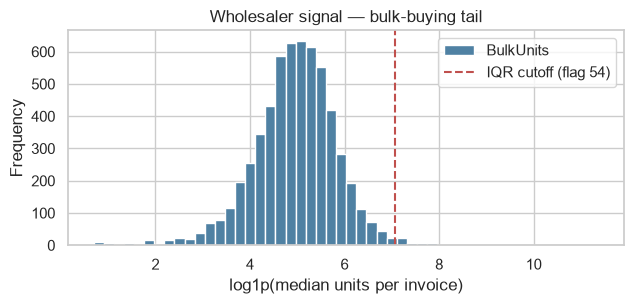

In [6]:
sup = features.build_supporting_features(tx, non_purchases)
lb = np.log1p(sup["BulkUnits"])
q1, q3 = lb.quantile([0.25, 0.75])
cutoff = q3 + 1.5 * (q3 - q1)                      # IQR upper fence
sup["IsWholesaler"] = lb > cutoff
n_w = int(sup["IsWholesaler"].sum())
print(f"wholesaler flag: BulkUnits > {np.expm1(cutoff):.0f} units/invoice  ->  {n_w:,} customers ({n_w/len(sup):.1%})")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
lb.plot.hist(bins=50, ax=ax, color="#4f81a3")
ax.axvline(cutoff, color="#c0504d", ls="--", lw=1.5, label=f"IQR cutoff (flag {n_w:,})")
ax.set_xlabel("log1p(median units per invoice)")
ax.set_title("Wholesaler signal — bulk-buying tail")
ax.legend()
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "wholesaler_tail.png"), dpi=150, bbox_inches="tight")
plt.show()

## Build all three lanes + the clustering matrix, then save

- **Core (scaled)** → `log1p` the skewed cols, then RobustScaler → the clustering matrix
- **CLV inputs** (raw, via PyMC-Marketing)
- **Supporting** (country, bulk + flag, return-rate)

In [7]:
clustering_matrix, scaler = features.scale_features(core, log_cols=LOG_COLS, cluster_cols=CLUSTER_COLS)
clv = features.build_clv_inputs(tx)

print("clustering matrix:", clustering_matrix.shape, "| clv inputs:", clv.shape, "| supporting:", sup.shape)
clustering_matrix.describe().round(2)

clustering matrix: (5852, 4) | clv inputs: (5852, 4) | supporting: (5852, 4)


,Recency,Frequency,Monetary,Tenure
count,"5,852.00","5,852.00","5,852.00","5,852.00"
mean,0.30,0.12,0.02,-0.16
std,0.59,0.58,0.73,0.63
min,-0.27,-0.50,-2.85,-1.49
25%,-0.20,-0.50,-0.49,-0.61
50%,0.00,0.00,-0.00,0.00
75%,0.80,0.50,0.51,0.39
max,1.82,3.27,3.46,0.59


In [8]:
proc = utils.DATA_PROCESSED
core.to_parquet(proc / "core_features.parquet")
clustering_matrix.to_parquet(proc / "clustering_matrix.parquet")
clv.to_parquet(proc / "clv_inputs.parquet")
sup.to_parquet(proc / "supporting_features.parquet")
joblib.dump(scaler, proc / "scaler_robust.joblib")     # persist the fitted scaler (doc 09)
print("saved: core_features, clustering_matrix, clv_inputs, supporting_features (+ scaler)")

saved: core_features, clustering_matrix, clv_inputs, supporting_features (+ scaler)


---
**Result:** three feature lanes built + a scaled clustering matrix (R/F/M/Tenure), all keyed by
Customer ID. Feature-EDA confirmed the `log1p` choice, the AvgBasket=M/F redundancy, and set the
wholesaler cutoff from the data.

**Next:** `04_clustering` — K-Means / GMM / Ward on the clustering matrix (docs 10, 11).